In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [260]:
floorspace = pd.read_csv('datasource-VIC_LGovt_COM-UoM_AURIN_DB_com_clue_floor_use_block_2016.csv')
floorspace.head()

,FID,block_id,census_year,clue_small_area,commercial_accommodation,common_area,community_use,educational_research,entertainment_recreation_indoor,equipment_installation,...,transport,transport_storage_uncovered,unoccupied_under_construction,unoccupied_under_demolition_condemned,unoccupied_under_renovation,unoccupied_undeveloped_site,unoccupied_unused,wholesale,workshop_studio,wkb_geometry
0,com_clue_floor_use_block_2016.662,662,2016,East Melbourne,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,MULTIPOLYGON (((-37.81761280329104 144.9899553...
1,com_clue_floor_use_block_2016.1112,1112,2016,Docklands,NaN,13539.0,0.0,0.0,216.0,0.0,...,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,MULTIPOLYGON (((-37.82336946617084 144.9479230...
2,com_clue_floor_use_block_2016.6,6,2016,Melbourne (CBD),0.0,15020.0,0.0,0.0,6645.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2532.0,MULTIPOLYGON (((-37.81909387846127 144.9714047...
3,com_clue_floor_use_block_2016.927,927,2016,Parkville,0.0,6061.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,MULTIPOLYGON (((-37.786628712217954 144.942615...
4,com_clue_floor_use_block_2016.926,926,2016,Parkville,0.0,236.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,MULTIPOLYGON (((-37.787565931994955 144.942136...


In [261]:
floorspace.info()

<class 'pandas.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   FID                                    606 non-null    str    
 1   block_id                               606 non-null    int64  
 2   census_year                            606 non-null    int64  
 3   clue_small_area                        606 non-null    str    
 4   commercial_accommodation               579 non-null    float64
 5   common_area                            544 non-null    float64
 6   community_use                          560 non-null    float64
 7   educational_research                   528 non-null    float64
 8   entertainment_recreation_indoor        486 non-null    float64
 9   equipment_installation                 474 non-null    float64
 10  hospital_clinic                        524 non-null    float64
 11  house_townhouse  

In [262]:
# Drop unnecessary ID and year columns
floorspace.drop(['FID','block_id','census_year'], axis=1, inplace=True)

# Holding onto the spatial data for possible later use
fsSpatial = floorspace[['wkb_geometry']].copy()

floorspace.drop(['wkb_geometry'], axis=1, inplace=True)


In [263]:
floorspace['clue_small_area'].value_counts(dropna=False)


clue_small_area
Kensington                      117
North Melbourne                  94
Melbourne (CBD)                  83
Carlton                          71
West Melbourne (Residential)     48
Southbank                        40
East Melbourne                   37
Parkville                        34
Port Melbourne                   20
Docklands                        17
South Yarra                      17
Melbourne (Remainder)            15
West Melbourne (Industrial)      13
Name: count, dtype: int64

In [264]:
floorspace.columns

Index(['clue_small_area', 'commercial_accommodation', 'common_area',
       'community_use', 'educational_research',
       'entertainment_recreation_indoor', 'equipment_installation',
       'hospital_clinic', 'house_townhouse', 'institutional_accommodation',
       'manufacturing', 'office', 'park_reserve', 'parking_commercial_covered',
       'parking_commercial_uncovered', 'parking_private_covered',
       'parking_private_uncovered', 'performances_conferences_ceremonies',
       'private_outdoor_space', 'public_display_area', 'residential_apartment',
       'retail_cars', 'retail_shop', 'retail_showroom', 'retail_stall',
       'sports_and_recreation_outdoor', 'square_promenade', 'storage',
       'student_accommodation', 'total_space_in_block', 'transport',
       'transport_storage_uncovered', 'unoccupied_under_construction',
       'unoccupied_under_demolition_condemned', 'unoccupied_under_renovation',
       'unoccupied_undeveloped_site', 'unoccupied_unused', 'wholesale',
    

In [265]:
floorspace.describe()

,commercial_accommodation,common_area,community_use,educational_research,entertainment_recreation_indoor,equipment_installation,hospital_clinic,house_townhouse,institutional_accommodation,manufacturing,...,total_space_in_block,transport,transport_storage_uncovered,unoccupied_under_construction,unoccupied_under_demolition_condemned,unoccupied_under_renovation,unoccupied_undeveloped_site,unoccupied_unused,wholesale,workshop_studio
count,579.000000,544.000000,560.000000,528.000000,486.000000,474.00000,524.000000,573.000000,587.000000,568.000000,...,6.060000e+02,592.000000,594.000000,579.000000,591.000000,553.000000,513.000000,521.000000,572.000000,489.000000
mean,1624.248705,9068.770221,105.585714,2460.984848,1959.679012,886.14135,1131.593511,2910.183246,144.231687,301.586268,...,8.406556e+04,93.755068,4822.786195,2379.582038,80.285956,379.180832,484.904483,2948.408829,60.263986,238.995910
std,4961.958168,17046.732732,1182.273794,12127.807596,6092.495959,2997.53743,10393.607730,4667.523217,1242.530527,3455.577071,...,1.654573e+05,1963.195368,49984.945216,18708.701121,1059.560951,2658.345032,4757.992296,15445.540366,617.197316,1182.736026
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,9.169900e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,177.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,1.208288e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1779.500000,0.000000,0.000000,0.000000,0.00000,0.000000,335.000000,0.000000,0.000000,...,2.745183e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,10491.750000,0.000000,0.000000,1304.500000,0.00000,0.000000,4621.000000,0.000000,0.000000,...,8.954369e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1862.000000,0.000000,0.000000
max,47401.000000,167307.000000,21617.000000,205252.000000,69146.000000,31413.00000,186441.000000,47534.000000,16241.000000,65309.000000,...,2.120803e+06,47322.000000,893180.000000,373172.000000,20022.000000,38482.000000,72070.000000,319847.000000,13086.000000,13406.000000


In [266]:
numeric_cols = floorspace.columns.difference(['clue_small_area', 'total_space_in_block'])
row_sums = floorspace[numeric_cols].sum(axis=1)

In [267]:
floorspace[numeric_cols].isna().sum()      # NULLs per category


commercial_accommodation                  27
common_area                               62
community_use                             46
educational_research                      78
entertainment_recreation_indoor          120
equipment_installation                   132
hospital_clinic                           82
house_townhouse                           33
institutional_accommodation               19
manufacturing                             38
office                                    79
park_reserve                             119
parking_commercial_covered                30
parking_commercial_uncovered              23
parking_private_covered                  128
parking_private_uncovered                 59
performances_conferences_ceremonies       83
private_outdoor_space                    126
public_display_area                       26
residential_apartment                     31
retail_cars                               12
retail_shop                               99
retail_sho

In [268]:
null_counts = floorspace[numeric_cols].isna().sum()
null_counts[null_counts > 0]          # only the columns that actually have NULLs
len(null_counts[null_counts > 0])     # how many columns are affected

37

In [269]:
floorspace[numeric_cols].isna().any(axis=1).sum()   # how many rows affected at all

np.int64(564)

In [270]:
# Find the difference between the sum of the individual floor space categories and the total space in block
diff = row_sums - floorspace['total_space_in_block']
diff.describe()


count    6.060000e+02
mean    -1.669512e+04
std      7.134701e+04
min     -1.286772e+06
25%     -6.923730e+03
50%     -2.607325e+03
75%     -9.577053e+02
max      1.730469e+00
dtype: float64

In [271]:
(diff < 0).sum()   # rows where row_sums is less than total

np.int64(588)

In [272]:
(diff > 0).sum()   # rows where row_sums exceeds total — should be 0 if all rows total less than or equal to total_space_in_block

np.int64(15)

In [273]:
# find the rows where the sum of the individual floor space categories exceeds the total space in block
over = floorspace[diff > 0]
diff[diff > 0].describe()   # how big are these overshoots?


count    15.000000
mean      0.753507
std       0.530898
min       0.009766
25%       0.405090
50%       0.689941
75%       1.026367
max       1.730469
dtype: float64

Difference is negligible for these overshoots, caused by rounding noise

In [274]:
# Impute missing values in each row, using the row's gap to fill and the column-level baseline as weights.

# 1. Column-level baseline, smoothed so no column is ever exactly 0
raw_baseline = floorspace[numeric_cols].median()
baseline = raw_baseline + 1   # small constant ensures every null cell gets some share

# 2. Per-row known sum and gap to fill
known_sum = floorspace[numeric_cols].sum(axis=1)   # NaNs skipped automatically
gap = floorspace['total_space_in_block'] - known_sum
gap = gap.clip(lower=0)   # handles the 15 overshoot rows — nothing left to distribute

# 3. Mask of which cells are null in each row
null_mask = floorspace[numeric_cols].isna()

# 4. Weight each null cell by its column's smoothed baseline, normalized within the row
weights = null_mask.mul(baseline, axis=1)                  # baseline value where null, else 0
row_weight_sum = weights.sum(axis=1).replace(0, 1)          # guard, shouldn't trigger now
proportions = weights.div(row_weight_sum, axis=0)           # each row's weights sum to 1
imputed_values = proportions.mul(gap, axis=0)                # scale to that row's gap

# 5. Fill: known values stay, nulls get their share of the gap
floorspace_filled = floorspace[numeric_cols].where(~null_mask, imputed_values)
floorspace_filled['total_space_in_block'] = floorspace['total_space_in_block']
floorspace_filled['clue_small_area'] = floorspace['clue_small_area']

In [275]:
filled_sums = floorspace_filled[numeric_cols].sum(axis=1)
diff_filled = filled_sums - floorspace_filled['total_space_in_block']

diff_filled.describe()

count    606.000000
mean       0.006769
std        0.162491
min       -1.020020
25%        0.000000
50%        0.000000
75%        0.000000
max        1.730469
dtype: float64

In [276]:
overshoot_diffs = diff_filled[diff_filled > 0]
overshoot_diffs.describe()
overshoot_diffs.sort_values()

247    9.094947e-13
574    9.094947e-13
560    9.094947e-13
314    9.094947e-13
596    9.094947e-13
           ...     
395    8.808594e-01
376    1.171875e+00
5      1.339844e+00
359    1.718750e+00
391    1.730469e+00
Length: 68, dtype: float64

In [277]:
# ignoring rounding noise of extremely small values, should still be your 15 overshoot rows (unchanged, untouched by imputation)
(diff_filled > 1e-6).sum()    

np.int64(15)

In [278]:
proportions = floorspace_filled[numeric_cols].div(floorspace_filled['total_space_in_block'], axis=0)

In [279]:
proportions.isna().sum().sum()   # confirm no NaNs introduced by the division


np.int64(0)

In [280]:
proportions.sum(axis=1).describe()   # sanity check — should be ~1 for most rows

count    606.000000
mean       1.000000
std        0.000018
min        0.999781
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000206
dtype: float64

In [281]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(proportions)

In [282]:
X_scaled_df = pd.DataFrame(X_scaled, columns=proportions.columns, index=proportions.index)

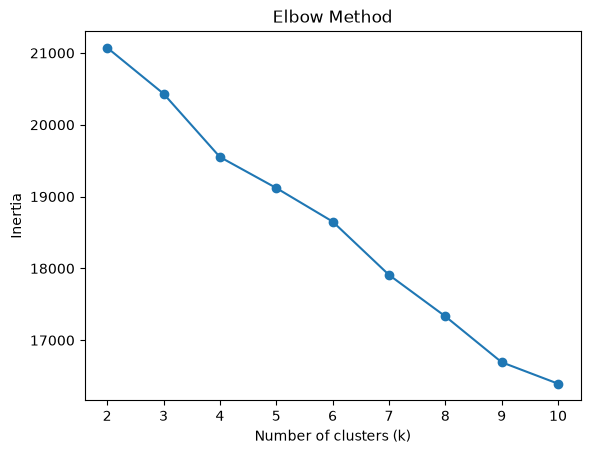

In [283]:
from sklearn.cluster import KMeans

# Elbow method to help choose k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

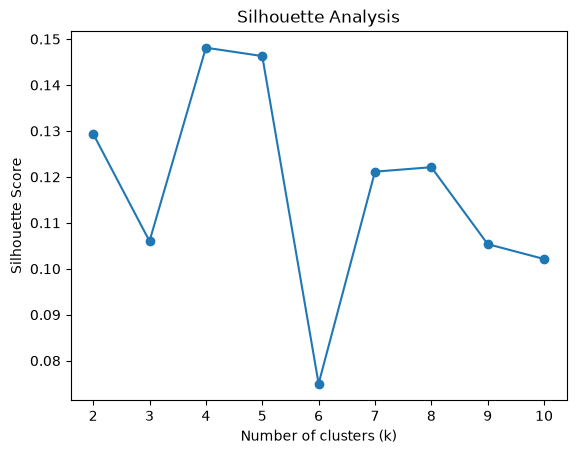

In [284]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

In [285]:
# No clear elbow due to too many features, using PCA to reduce dimensionality before clustering

from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)   # keep enough components to explain 90% of variance
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)   # how many components that took

(606, 30)


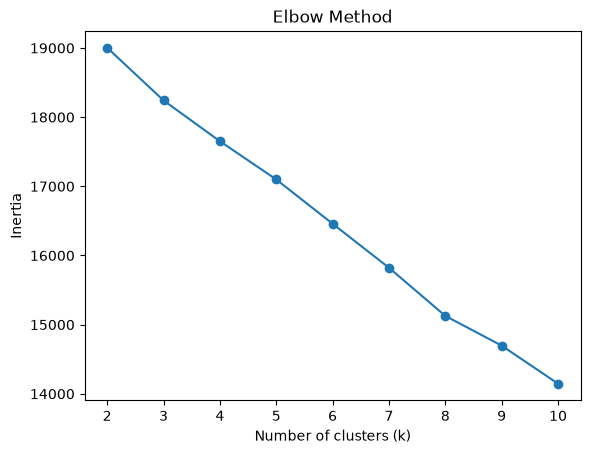

In [286]:
# Elbow method to help choose k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [287]:
for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    print(f"k={k}, silhouette={silhouette_score(X_scaled, labels):.4f}")
    print(pd.Series(labels).value_counts().sort_index())
    print()

k=4, silhouette=0.1481
0     31
1    291
2    240
3     44
Name: count, dtype: int64

k=5, silhouette=0.1463
0    240
1     32
2      6
3     49
4    279
Name: count, dtype: int64



In [288]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

floorspace_filled['cluster'] = clusters
floorspace_filled['cluster'].value_counts().sort_index()

# Centroid profiles in proportion terms — what each cluster is dominated by
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=proportions.columns
)
centroids.round(3)

,commercial_accommodation,common_area,community_use,educational_research,entertainment_recreation_indoor,equipment_installation,hospital_clinic,house_townhouse,institutional_accommodation,manufacturing,...,student_accommodation,transport,transport_storage_uncovered,unoccupied_under_construction,unoccupied_under_demolition_condemned,unoccupied_under_renovation,unoccupied_undeveloped_site,unoccupied_unused,wholesale,workshop_studio
0,-0.000,0.007,0.098,0.000,0.013,0.059,0.000,0.000,0.000,0.000,...,0.000,0.011,0.008,-0.000,-0.000,0.000,0.019,0.000,-0.000,-0.000
1,0.003,0.053,0.002,0.016,0.006,0.002,0.003,0.330,0.002,0.001,...,0.005,0.000,0.013,0.004,0.000,0.001,0.012,0.006,0.000,0.003
2,0.031,0.150,0.001,0.035,0.032,0.014,0.017,0.039,0.002,0.000,...,0.013,0.002,0.000,0.035,0.002,0.009,0.004,0.037,0.001,0.006
3,0.001,0.054,0.002,0.008,0.007,0.003,0.000,0.029,-0.000,0.059,...,0.000,0.000,0.045,0.007,0.000,0.000,0.009,0.112,0.026,0.052


In [289]:
for i in range(k):
    top_categories = centroids.loc[i].sort_values(ascending=False).head(5)
    print(f"Cluster {i}:")
    print(top_categories)
    print()

Cluster 0:
park_reserve                    0.749367
community_use                   0.098314
equipment_installation          0.058647
unoccupied_undeveloped_site     0.018817
parking_commercial_uncovered    0.016129
Name: 0, dtype: float64

Cluster 1:
private_outdoor_space    0.361321
house_townhouse          0.330083
residential_apartment    0.092042
common_area              0.052658
office                   0.036562
Name: 1, dtype: float64

Cluster 2:
residential_apartment      0.167389
office                     0.156077
common_area                0.150423
parking_private_covered    0.072764
private_outdoor_space      0.068985
Name: 2, dtype: float64

Cluster 3:
private_outdoor_space    0.282341
storage                  0.135875
unoccupied_unused        0.112303
office                   0.102152
manufacturing            0.059212
Name: 3, dtype: float64



In [291]:
pd.crosstab(floorspace_filled['clue_small_area'], floorspace_filled['cluster'])

cluster,0,1,2,3
clue_small_area,,,,
Carlton,3,31,37,0
Docklands,0,6,11,0
East Melbourne,4,15,18,0
Kensington,8,95,3,11
Melbourne (CBD),1,5,77,0
Melbourne (Remainder),4,4,7,0
North Melbourne,4,48,29,13
Parkville,0,29,5,0
Port Melbourne,1,12,0,7
